In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading and Preprocessing Data with PIL.

Loading the Data

• Download the provided folder that contains the Devnagari digits dataset.

• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.

• use train folder for training and test for testing.

• Extract the corresponding labels for each image.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.utils import to_categorical

# Dataset paths
train_dir = "/content/drive/MyDrive/AI Sem6/Worksheet4/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI Sem6/Worksheet4/DevanagariHandwrittenDigitDataset/Test"

# Image settings
img_height = 28
img_width = 28
num_classes = 10

def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))   # digit_0, digit_1, ..., digit_9
    class_map = {name: i for i, name in enumerate(class_names)}

    print("Class mapping:", class_map)

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                img = Image.open(img_path).convert("L")         # grayscale
                img = img.resize((img_width, img_height))      # resize to 28x28
                img = np.array(img, dtype=np.float32) / 255.0  # normalize

                images.append(img)
                labels.append(label)

            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

# Load dataset
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape for keras
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
x_train shape: (17000, 28, 28, 1)
y_train shape: (17000, 10)
x_test shape : (3000, 28, 28, 1)
y_test shape : (3000, 10)


### Visualize Sample Images

Let's visualize some of the preprocessed training images to ensure the data loading and transformation steps were successful.

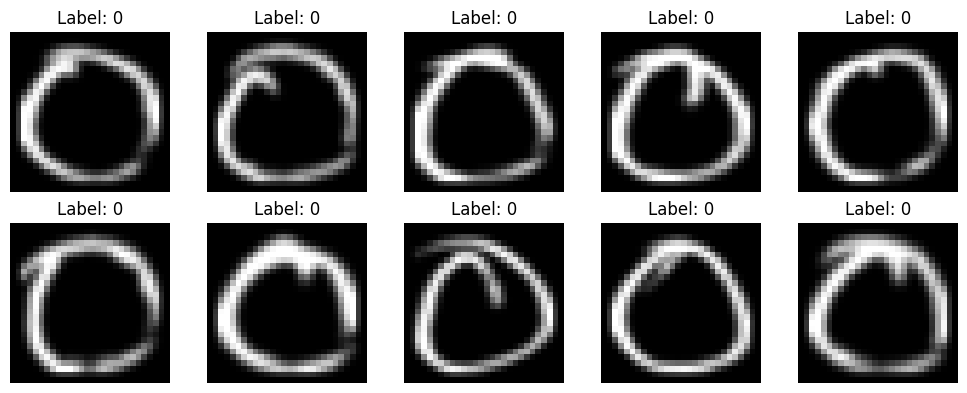

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Task 2: Build the FCN Model

Model Architecture

• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:

– 1st hidden layer: 64 neurons

– 2nd hidden layer: 128 neurons

– 3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense

model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(64, activation="sigmoid"),
    Dense(128, activation="sigmoid"),
    Dense(256, activation="sigmoid"),
    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Task 3: Compile the Model

Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [5]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Task 4: Train the Model

Model Training

• Use the model.fit() function to train the model. Set the batch size to 128 and the number of
epochs to 20.

• Use validation split (validation split=0.2) to monitor the model’s performance on validation
data.

• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model
and avoiding overfitting.

In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_devnagari_fcn.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/20
 98/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2853 - loss: 1.9627
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_devnagari_fcn.h5



Epoch 1: finished saving model to best_devnagari_fcn.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5123 - loss: 1.5561 - val_accuracy: 0.0000e+00 - val_loss: 7.3054
Epoch 2/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8188 - loss: 0.5744
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8432 - loss: 0.4751 - val_accuracy: 0.0000e+00 - val_loss: 8.5297
Epoch 3/20
 98/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9000 - loss: 0.3105
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9129 - loss: 0.2851 - val_accuracy: 0.0000e+00 - val_loss: 9.1547
Epoch 4/20
 96/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9383 - loss: 0.2079
Epoch 4: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9454 - loss: 0.1906 - val_accuracy: 0.0000e+00 - val_loss: 9.3877
Epoch 5/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/s

Task 5: Evaluate the Model

Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

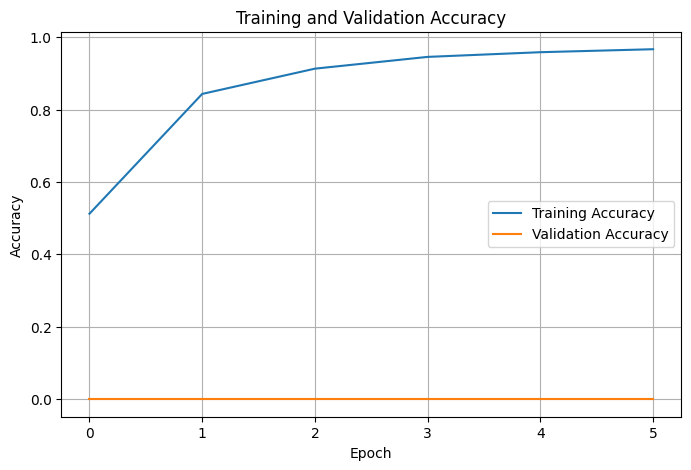

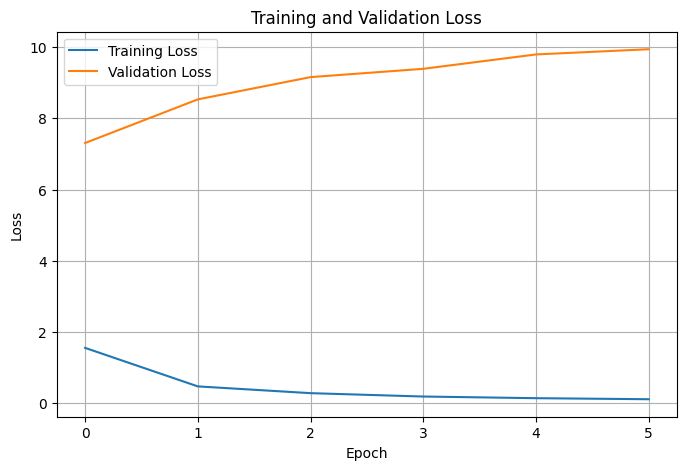

In [7]:
# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6287 - loss: 2.0437
Test Loss: 2.0437262058258057
Test Accuracy: 0.6286666393280029


Task 6: Save and Load the Model

Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [9]:
from tensorflow.keras.models import load_model

# Save model
model.save("devnagari_fcn_model.h5")
print("Model saved successfully.")

# Load model
loaded_model = load_model("devnagari_fcn_model.h5")
print("Model loaded successfully.")

# Re-evaluate loaded model
loaded_loss, loaded_accuracy = loaded_model.evaluate(x_test, y_test, verbose=1)

print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_accuracy)

Model saved successfully.


Model loaded successfully.
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6287 - loss: 2.0437
Loaded Model Test Loss: 2.0437262058258057
Loaded Model Test Accuracy: 0.6286666393280029


Task 7: Predictions

Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

In [10]:
# Predict probabilities
predictions = loaded_model.predict(x_test)

# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("First 10 predicted labels:", predicted_labels[:10])
print("First 10 true labels     :", true_labels[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
First 10 predicted labels: [0 0 0 0 0 0 0 0 0 0]
First 10 true labels     : [0 0 0 0 0 0 0 0 0 0]


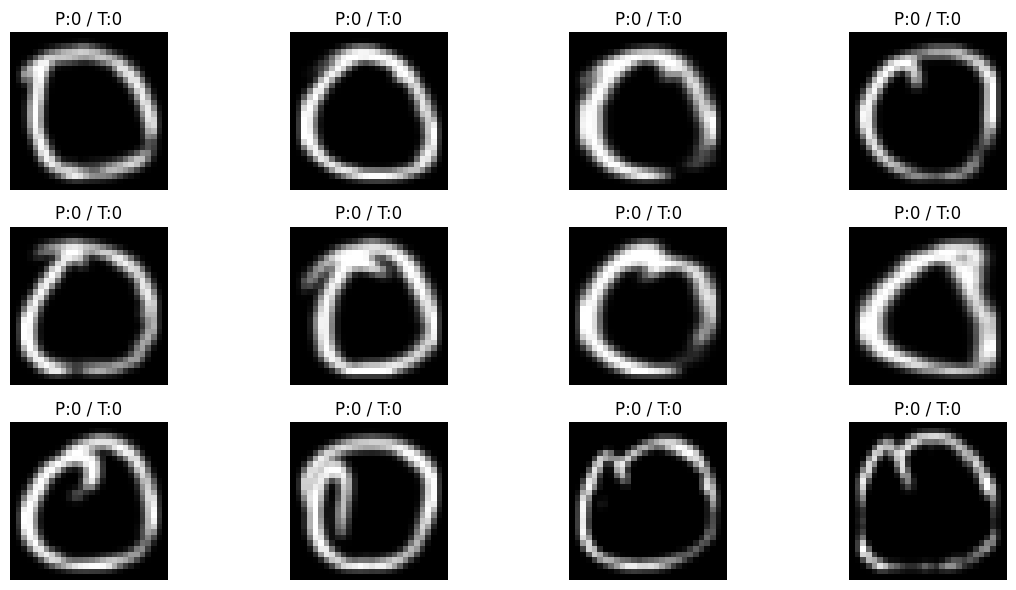

In [11]:
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"P:{predicted_labels[i]} / T:{true_labels[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()